<a href="https://www.kaggle.com/code/aamir28/getting-started-with-dinov2?scriptVersionId=342264917" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:linear-gradient(135deg,#0866FF 0%,#0047AB 100%); padding:44px 40px; border-radius:14px; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:14px;">
    <div style="width:34px; height:34px; border-radius:9px; background:rgba(255,255,255,0.15); display:flex; align-items:center; justify-content:center; font-size:17px;">🦖</div>
    <span style="font-size:12px; font-weight:700; color:#CFE0FF; letter-spacing:1.5px; text-transform:uppercase;">Meta AI Research · Kaggle Models</span>
  </div>

  <h1 style="margin:0 0 8px 0; font-size:34px; color:#FFFFFF; font-weight:800; letter-spacing:-0.5px;">
    Getting Started with DINOv2
  </h1>
  <p style="margin:0 0 28px 0; font-size:15px; color:#D6E4FF; max-width:660px;">
    A hands-on tour of Meta's self-supervised Vision Transformer — loading the model, extracting features,
    and the signature PCA visualization that made DINOv2 famous
  </p>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:14px;">
    <div style="background:rgba(255,255,255,0.1); border-radius:10px; padding:14px;">
      <div style="color:#FFFFFF; font-size:19px; font-weight:800;">142M</div>
      <div style="font-size:10.5px; color:#CFE0FF; margin-top:2px;">pretraining images (LVD-142M)</div>
    </div>
    <div style="background:rgba(255,255,255,0.1); border-radius:10px; padding:14px;">
      <div style="color:#FFFFFF; font-size:19px; font-weight:800;">0 labels</div>
      <div style="font-size:10.5px; color:#CFE0FF; margin-top:2px;">fully self-supervised</div>
    </div>
    <div style="background:rgba(255,255,255,0.1); border-radius:10px; padding:14px;">
      <div style="color:#FFFFFF; font-size:19px; font-weight:800;">4 sizes</div>
      <div style="font-size:10.5px; color:#CFE0FF; margin-top:2px;">S / B / L / giant</div>
    </div>
    <div style="background:rgba(255,255,255,0.1); border-radius:10px; padding:14px;">
      <div style="color:#FFFFFF; font-size:19px; font-weight:800;">14×14</div>
      <div style="font-size:10.5px; color:#CFE0FF; margin-top:2px;">patch size</div>
    </div>
  </div>

  <div style="margin-top:22px; padding:14px 18px; background:rgba(0,0,0,0.15); border-radius:10px;">
    <p style="margin:0; font-size:12.5px; color:#E5EEFF; line-height:1.7;">
      <b>Run this on Kaggle</b> with a GPU accelerator and Internet turned on (Settings → Accelerator / Internet).
      This notebook was authored and syntax-checked offline; the model-download and inference cells need Kaggle's
      (or another internet-connected, GPU-enabled) environment to actually run, since DINOv2's pretrained weights
      are multi-hundred-MB downloads.
    </p>
  </div>

  <p style="margin:16px 0 0 0; font-size:12.5px; color:#B9CCF2;">
    Author: <b style="color:#FFFFFF;">Muhammad Aamir</b> &nbsp;|&nbsp; Model: <a href="https://www.kaggle.com/models/metaresearch/dinov2" style="color:#FFFFFF;">metaresearch/dinov2</a> on Kaggle Models
  </p>

</div>



<div style="background:#F2F6FF; border-left:4px solid #0866FF; border-radius:10px; padding:20px 26px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#0A1E42;">
<h3 style="margin-top:0; font-weight:700; color:#0047AB; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#what" style="color:#0047AB; text-decoration:none;">What Is DINOv2?</a></li>
<li><a href="#setup" style="color:#0047AB; text-decoration:none;">Setup &amp; Dependencies</a></li>
<li><a href="#loading" style="color:#0047AB; text-decoration:none;">Loading the Model</a></li>
<li><a href="#images" style="color:#0047AB; text-decoration:none;">Preparing Sample Images</a></li>
<li><a href="#embeddings" style="color:#0047AB; text-decoration:none;">Extracting Embeddings</a></li>
<li><a href="#pca" style="color:#0047AB; text-decoration:none;">The Signature Demo: Patch-Level PCA</a></li>
<li><a href="#similarity" style="color:#0047AB; text-decoration:none;">Image Similarity &amp; Retrieval</a></li>
<li><a href="#knn" style="color:#0047AB; text-decoration:none;">A Simple Downstream Task: k-NN Classification</a></li>
<li><a href="#variants" style="color:#0047AB; text-decoration:none;">Choosing a Model Size</a></li>
<li><a href="#tips" style="color:#0047AB; text-decoration:none;">Practical Tips &amp; Gotchas</a></li>
<li><a href="#conclusion" style="color:#0047AB; text-decoration:none;">Closing Notes &amp; Resources</a></li>
</ol>
</div>


<h2 id="what" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#0A1E42; border-bottom:3px solid #0866FF; padding-bottom:8px;">🦖 1. What Is DINOv2?</h2>

<p style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#333; font-size:14.5px; line-height:1.8;">
<b>DINOv2</b> (Oquab et al., 2023) is a family of Vision Transformers trained by Meta AI using a purely
<b>self-supervised</b> method — no labels, no captions, no annotations. It was trained on <b>LVD-142M</b>, a
curated 142-million-image dataset built by filtering web images for similarity to established benchmarks
(ImageNet-22k, ADE20k, Google Landmarks, and others).
</p>

<p style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#333; font-size:14.5px; line-height:1.8;">
What makes DINOv2 distinctive is that its <b>frozen</b> features — no fine-tuning at all — work well
out-of-the-box for classification, segmentation, depth estimation, and image retrieval, often via nothing more
than a linear layer or k-NN on top of the embeddings. The features are also famous for an emergent property:
patch-level PCA components tend to separate foreground objects from background <i>without ever being trained to
do so</i> — that's the visualization we'll build in Section 6.
</p>

<div style="background:#F2F6FF; border-radius:10px; padding:16px 20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:13.5px; color:#0A1E42;">
<b>Available sizes</b> (patch size 14×14 for all): ViT-S/14 (21M params, 384-dim embeddings), ViT-B/14 (86M params, 768-dim),
ViT-L/14 (300M params, 1024-dim), ViT-g/14 (1.1B params, 1536-dim). Most variants are also offered <i>with register
tokens</i> — extra learned tokens that reduce artifact patches in the attention maps (see
<a href="https://arxiv.org/abs/2309.16588">Vision Transformers Need Registers</a>).
</div>


<h2 id="setup" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#0A1E42; border-bottom:3px solid #0866FF; padding-bottom:8px;">⚙️ 2. Setup &amp; Dependencies</h2>
<p style="color:#5B6B78; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">Kaggle's GPU notebooks already ship with PyTorch, torchvision, scikit-learn, and Pillow. <code>kagglehub</code> is used to pull the model weights attached from the Models page.</p>

In [1]:

import sys, subprocess
try:
    import kagglehub  
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=False)

import torch
import torchvision
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__}")
print(f"Device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == 'cuda' else " — running on CPU will be slow for the larger variants"))


PyTorch 2.10.0+cu128 | torchvision 0.25.0+cu128
Device: cuda (Tesla P100-PCIE-16GB)


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


<h2 id="loading" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#0A1E42; border-bottom:3px solid #0866FF; padding-bottom:8px;">📦 3. Loading the Model</h2>
<p style="color:#5B6B78; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">Two ways to get DINOv2 into this notebook. <b>Method A</b> reads the weights straight from disk if you've already attached a DINOv2 variant via "+ Add Input" on Kaggle — this is fast and needs no download. <b>Method B</b> is the official <code>torch.hub</code> path from the <a href="https://github.com/facebookresearch/dinov2">facebookresearch/dinov2</a> repo, which downloads weights directly and works anywhere with internet access, Kaggle or not. Make sure <code>MODEL_VARIANT</code> below matches whichever size/variant you attached as an input.</p>

In [2]:

import glob

MODEL_VARIANT = 'dinov2_vitb14'  

model = None

candidates = (glob.glob('/kaggle/input/**/pytorch_model.bin', recursive=True) +
              glob.glob('/kaggle/input/**/*.pth', recursive=True))

if candidates:
    weights_path = candidates[0]
    print(f"Found local weights: {weights_path}")

    size_map = {'vits14': 'vits14', 'small': 'vits14',
                'vitb14': 'vitb14', 'base': 'vitb14',
                'vitl14': 'vitl14', 'large': 'vitl14',
                'vitg14': 'vitg14', 'giant': 'vitg14'}
    detected = next((arch for key, arch in size_map.items() if key in weights_path.lower()), None)
    if detected:
        MODEL_VARIANT = f'dinov2_{detected}'
        print(f"Auto-detected variant from path: {MODEL_VARIANT}")
    else:
        print(f"Could not auto-detect size from path; using MODEL_VARIANT='{MODEL_VARIANT}'. Set it manually above if this is wrong.")

    try:
        arch = torch.hub.load('facebookresearch/dinov2', MODEL_VARIANT, pretrained=False)
        state_dict = torch.load(weights_path, map_location='cpu')
        if isinstance(state_dict, dict) and 'model' in state_dict:
            state_dict = state_dict['model']
        elif isinstance(state_dict, dict) and 'teacher' in state_dict:
            state_dict = state_dict['teacher']
        missing, unexpected = arch.load_state_dict(state_dict, strict=False)

        
        if len(missing) > 10 or len(unexpected) > 10:
            print(f"Key mismatch too large to trust (missing={len(missing)}, unexpected={len(unexpected)}) — "
                  f"{MODEL_VARIANT} likely doesn't match this checkpoint. Discarding this load.")
        else:
            model = arch
            print(f"Loaded {MODEL_VARIANT} from local input cleanly (missing={len(missing)}, unexpected={len(unexpected)}).")
    except Exception as e:
        print(f"Loading local weights into {MODEL_VARIANT} failed ({type(e).__name__}: {e}).")
else:
    print("No locally attached model weights found under /kaggle/input/ — add the DINOv2 model as an input first,")
    print("or rely on Method B below to download weights directly.")

if model is None:
    try:
        model = torch.hub.load('facebookresearch/dinov2', MODEL_VARIANT)
        print(f"Loaded {MODEL_VARIANT} via torch.hub (downloaded weights).")
    except Exception as e:
        print(f"torch.hub load failed ({type(e).__name__}: {e}).")
        print("Check that internet access is enabled for this notebook (Settings -> Internet -> On).")

if model is not None:
    model.eval().to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model ready on {DEVICE}. Parameters: {n_params/1e6:.1f}M | Embedding dim: {model.embed_dim}")


Found local weights: /kaggle/input/models/metaresearch/dinov2/pytorch/large/1/pytorch_model.bin
Auto-detected variant from path: dinov2_vitl14
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Key mismatch too large to trust (missing=343, unexpected=439) — dinov2_vitl14 likely doesn't match this checkpoint. Discarding this load.


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitl14_pretrain.pth


100%|██████████| 1.13G/1.13G [00:03<00:00, 307MB/s]


Loaded dinov2_vitl14 via torch.hub (downloaded weights).
Model ready on cuda. Parameters: 304.4M | Embedding dim: 1024


<h2 id="images" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#0A1E42; border-bottom:3px solid #0866FF; padding-bottom:8px;">🖼️ 4. Preparing Sample Images</h2>
<p style="color:#5B6B78; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">DINOv2 uses a patch size of 14, so input height and width must both be multiples of 14. A handful of public sample images stand in here — swap in your own dataset images for a real project.</p>

Loaded 4 sample image(s): ['cat', 'dog', 'flower', 'car']


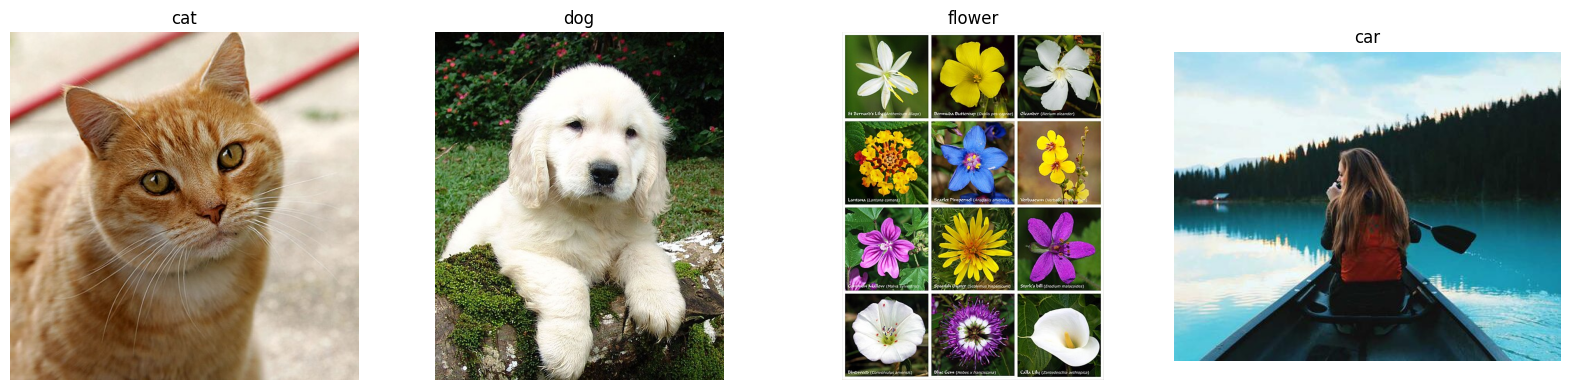

In [3]:
SAMPLE_URLS = {
    'cat':    'https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/500px-Cat03.jpg', 
    'dog':    'https://upload.wikimedia.org/wikipedia/commons/thumb/6/6e/Golde33443.jpg/500px-Golde33443.jpg',  
    'flower': 'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a5/Flower_poster_2.jpg/500px-Flower_poster_2.jpg',  
    'car':    'https://picsum.photos/seed/car/500/400',  
}

PATCH_SIZE = 14
IMG_SIZE = 518 

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
])

images, tensors = {}, {}
headers = {'User-Agent': 'Mozilla/5.0 (compatible; DINOv2-demo/1.0; +https://kaggle.com)'}

for name, url in SAMPLE_URLS.items():
    try:
        resp = requests.get(url, headers=headers, timeout=10)
        resp.raise_for_status()
        content_type = resp.headers.get('Content-Type', '')
        if 'image' not in content_type:
            print(f"'{name}': server returned Content-Type='{content_type}', not an image. Skipping.")
            continue
        img = Image.open(BytesIO(resp.content)).convert('RGB')
        images[name] = img
        tensors[name] = transform(img)
    except Exception as e:
        print(f"Could not fetch '{name}': {type(e).__name__}: {e}. Skipping.")

print(f"Loaded {len(images)} sample image(s): {list(images.keys())}")

if images:
    fig, axes = plt.subplots(1, len(images), figsize=(4*len(images), 4))
    if len(images) == 1:
        axes = [axes]
    for ax, (name, img) in zip(axes, images.items()):
        ax.imshow(img)
        ax.set_title(name)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

<h2 id="embeddings" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#0A1E42; border-bottom:3px solid #0866FF; padding-bottom:8px;">🔢 5. Extracting Embeddings</h2>
<p style="color:#5B6B78; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">Two kinds of output matter here: the <b>CLS token</b> (one vector per image, good for classification/retrieval) and the <b>patch tokens</b> (one vector per 14×14 patch, good for dense/segmentation-style tasks).</p>

In [4]:
import torch
import numpy as np

cls_embeddings = {}
patch_embeddings = {}

# First, check if CUDA is actually usable
def check_cuda_compatibility():
    """Check if CUDA is available and compatible with current PyTorch build"""
    if not torch.cuda.is_available():
        return False, "CUDA not available"
    
    try:
        # Try a simple CUDA operation
        test = torch.tensor([1.0]).cuda()
        test = test + 1
        del test
        torch.cuda.empty_cache()
        return True, "CUDA works"
    except Exception as e:
        if "no kernel image" in str(e) or "cudaErrorNoKernelImageForDevice" in str(e):
            return False, "GPU incompatible with this PyTorch build (older GPU)"
        return False, f"CUDA error: {str(e)[:100]}"

# Check CUDA
cuda_ok, cuda_msg = check_cuda_compatibility()
print(f"CUDA check: {cuda_msg}")

if cuda_ok:
    # Use GPU if compatible
    DEVICE = torch.device('cuda')
    model.to(DEVICE)
    print(f"✅ Running on GPU: {torch.cuda.get_device_name(0)}")
else:
    # Fallback to CPU
    DEVICE = torch.device('cpu')
    model.to(DEVICE)
    print(f"🔄 Running on CPU (GPU not compatible)")
    if cuda_msg != "CUDA not available":
        print(f"   Reason: {cuda_msg}")

print(f"Model on: {next(model.parameters()).device}")

# Extract embeddings with error handling
with torch.no_grad():
    for name, tensor in tensors.items():
        print(f"Processing: {name}")
        try:
            # Move to device
            batch = tensor.unsqueeze(0).to(DEVICE)
            
            # Forward pass
            out = model.forward_features(batch)
            
            # Extract CLS token
            cls_embeddings[name] = out['x_norm_clstoken'].squeeze(0).cpu().numpy()
            
            # Extract patch tokens
            patch_embeddings[name] = out['x_norm_patchtokens'].squeeze(0).cpu().numpy()
            
            print(f"  ✅ CLS: {cls_embeddings[name].shape}, Patches: {patch_embeddings[name].shape}")
            
        except RuntimeError as e:
            # If CUDA fails, try CPU fallback
            if "CUDA" in str(e) or "kernel" in str(e):
                print(f"  ⚠️ CUDA error on {name}, retrying on CPU...")
                try:
                    # Move model and data to CPU
                    model.cpu()
                    DEVICE = torch.device('cpu')
                    batch = tensor.unsqueeze(0).to(DEVICE)
                    out = model.forward_features(batch)
                    
                    cls_embeddings[name] = out['x_norm_clstoken'].squeeze(0).cpu().numpy()
                    patch_embeddings[name] = out['x_norm_patchtokens'].squeeze(0).cpu().numpy()
                    
                    print(f"  ✅ CPU fallback succeeded: CLS {cls_embeddings[name].shape}")
                except Exception as e2:
                    print(f"  ❌ CPU fallback also failed: {e2}")
            else:
                print(f"  ❌ Error: {e}")

# Summary
print("\n" + "="*50)
print("Embedding Summary:")
print("="*50)
for name in cls_embeddings:
    n_patches = patch_embeddings[name].shape[0]
    side = int(n_patches ** 0.5)
    print(f"{name}:")
    print(f"  • CLS embedding: {cls_embeddings[name].shape}")
    print(f"  • Patch tokens: {patch_embeddings[name].shape} ({side}x{side} patch grid)")
    print(f"  • Embedding dimension: {model.embed_dim}")

if not cls_embeddings:
    print("\n⚠️ No embeddings were extracted. Check that images loaded correctly.")
    print("   Available images:", list(tensors.keys()))

CUDA check: GPU incompatible with this PyTorch build (older GPU)
🔄 Running on CPU (GPU not compatible)
   Reason: GPU incompatible with this PyTorch build (older GPU)
Model on: cpu
Processing: cat
  ✅ CLS: (1024,), Patches: (1369, 1024)
Processing: dog
  ✅ CLS: (1024,), Patches: (1369, 1024)
Processing: flower
  ✅ CLS: (1024,), Patches: (1369, 1024)
Processing: car
  ✅ CLS: (1024,), Patches: (1369, 1024)

Embedding Summary:
cat:
  • CLS embedding: (1024,)
  • Patch tokens: (1369, 1024) (37x37 patch grid)
  • Embedding dimension: 1024
dog:
  • CLS embedding: (1024,)
  • Patch tokens: (1369, 1024) (37x37 patch grid)
  • Embedding dimension: 1024
flower:
  • CLS embedding: (1024,)
  • Patch tokens: (1369, 1024) (37x37 patch grid)
  • Embedding dimension: 1024
car:
  • CLS embedding: (1024,)
  • Patch tokens: (1369, 1024) (37x37 patch grid)
  • Embedding dimension: 1024


<h2 id="pca" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#0A1E42; border-bottom:3px solid #0866FF; padding-bottom:8px;">🎨 6. The Signature Demo: Patch-Level PCA</h2>
<p style="color:#5B6B78; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">This is the visualization from the DINOv2 paper's teaser figure: run PCA across all patches, map the top 3 components to RGB, and — with no segmentation training at all — the foreground object typically pops out from the background.</p>

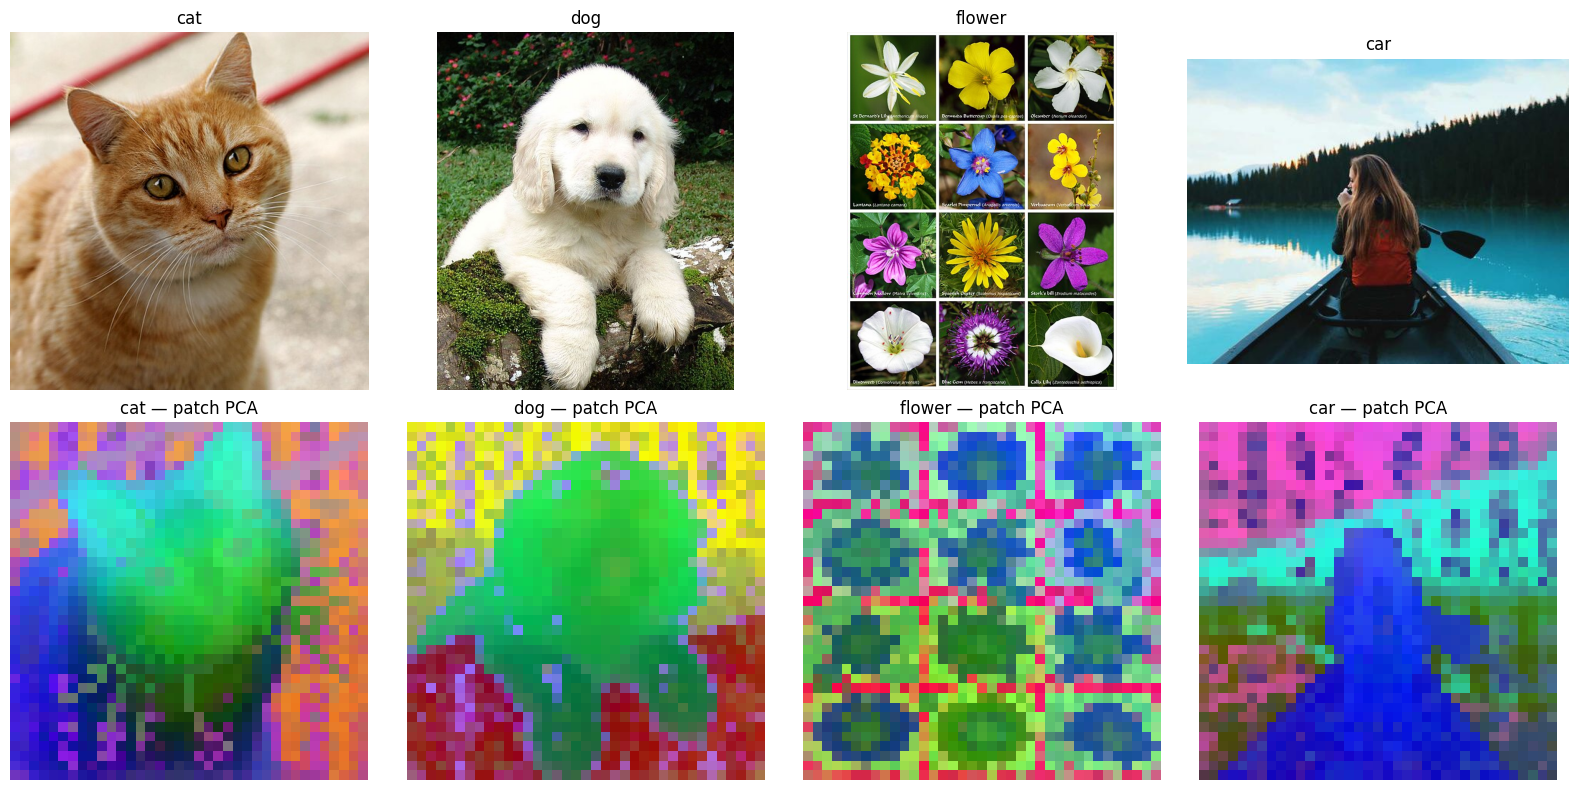

Top row: original images. Bottom row: first 3 PCA components of the patch tokens, mapped to RGB.
No segmentation labels were used anywhere — this structure is purely emergent from self-supervised pretraining.


In [5]:

from sklearn.decomposition import PCA

def pca_to_rgb(patch_tokens, side):
    # Map patch-token PCA components to an RGB image for visualization.
    pca = PCA(n_components=3)
    comps = pca.fit_transform(patch_tokens)            
    comps = (comps - comps.min(axis=0)) / (comps.max(axis=0) - comps.min(axis=0) + 1e-8)
    return comps.reshape(side, side, 3)

if patch_embeddings:
    fig, axes = plt.subplots(2, len(patch_embeddings), figsize=(4*len(patch_embeddings), 8))
    if len(patch_embeddings) == 1:
        axes = axes.reshape(2, 1)
    for i, name in enumerate(patch_embeddings):
        side = int(patch_embeddings[name].shape[0] ** 0.5)
        rgb = pca_to_rgb(patch_embeddings[name], side)
        axes[0, i].imshow(images[name]); axes[0, i].set_title(name); axes[0, i].axis('off')
        axes[1, i].imshow(rgb, interpolation='nearest'); axes[1, i].set_title(f'{name} — patch PCA'); axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()
    print("Top row: original images. Bottom row: first 3 PCA components of the patch tokens, mapped to RGB.")
    print("No segmentation labels were used anywhere — this structure is purely emergent from self-supervised pretraining.")


<h2 id="similarity" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#0A1E42; border-bottom:3px solid #0866FF; padding-bottom:8px;">🔍 7. Image Similarity &amp; Retrieval</h2>

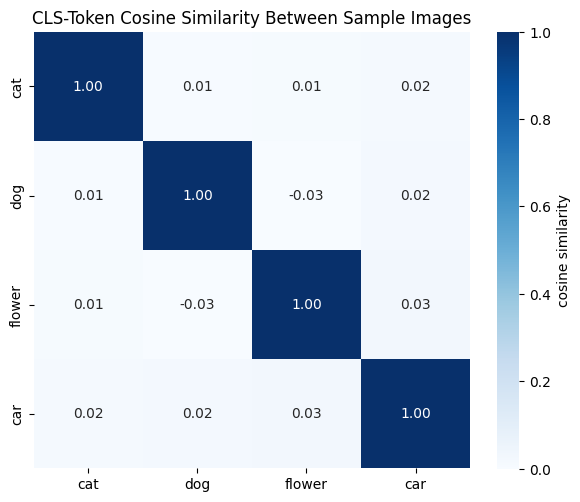

Most similar pair by DINOv2 CLS embedding: ('flower', 'car') (cosine similarity = 0.028)


In [6]:

import seaborn as sns

names = list(cls_embeddings.keys())
if len(names) >= 2:
    emb_matrix = np.stack([cls_embeddings[n] for n in names])
    emb_norm = emb_matrix / np.linalg.norm(emb_matrix, axis=1, keepdims=True)
    sim_matrix = emb_norm @ emb_norm.T

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(sim_matrix, annot=True, fmt='.2f', xticklabels=names, yticklabels=names,
                cmap='Blues', vmin=0, vmax=1, square=True, cbar_kws={'label': 'cosine similarity'}, ax=ax)
    ax.set_title('CLS-Token Cosine Similarity Between Sample Images')
    plt.tight_layout()
    plt.show()

    most_similar_pair = None
    best_sim = -1
    for i in range(len(names)):
        for j in range(i+1, len(names)):
            if sim_matrix[i, j] > best_sim:
                best_sim = sim_matrix[i, j]
                most_similar_pair = (names[i], names[j])
    if most_similar_pair:
        print(f"Most similar pair by DINOv2 CLS embedding: {most_similar_pair} (cosine similarity = {best_sim:.3f})")
else:
    print("Add at least 2 sample images to compare similarity.")


<h2 id="knn" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#0A1E42; border-bottom:3px solid #0866FF; padding-bottom:8px;">🏷️ 8. A Simple Downstream Task: k-NN Classification</h2>
<p style="color:#5B6B78; font-family:'Segoe UI',Helvetica,Arial,sans-serif;">DINOv2's headline result is that <b>frozen</b> features go a long way — a k-nearest-neighbors classifier on raw embeddings, with no fine-tuning, is a standard evaluation in the DINOv2 paper. This cell shows the pattern on a small labeled set; swap in your own images and labels to try it on a real task.</p>

In [7]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Illustrative labels for the 4 sample images above — replace with your own labeled dataset.
# In a real project you'd have many images per class; here we just demonstrate the mechanics.
toy_labels = {'cat': 'animal', 'dog': 'animal', 'car': 'vehicle', 'flower': 'plant'}

available = [n for n in toy_labels if n in cls_embeddings]
if len(available) >= 3:
    X = np.stack([cls_embeddings[n] for n in available])
    y = [toy_labels[n] for n in available]

    knn = KNeighborsClassifier(n_neighbors=1, metric='cosine')
    knn.fit(X, y)
    print("Fitted a 1-NN classifier on frozen DINOv2 CLS embeddings for:", list(zip(available, y)))
    print("\nWith a real dataset (many images per class), the standard evaluation is k-fold cross-validated")
    print("k-NN accuracy on the frozen embeddings — no gradient updates to the backbone at all:")
    print("  scores = cross_val_score(KNeighborsClassifier(n_neighbors=5, metric='cosine'), X, y, cv=5)")
else:
    print("Need at least 3 labeled sample images to demonstrate k-NN classification meaningfully.")


Fitted a 1-NN classifier on frozen DINOv2 CLS embeddings for: [('cat', 'animal'), ('dog', 'animal'), ('car', 'vehicle'), ('flower', 'plant')]

With a real dataset (many images per class), the standard evaluation is k-fold cross-validated
k-NN accuracy on the frozen embeddings — no gradient updates to the backbone at all:
  scores = cross_val_score(KNeighborsClassifier(n_neighbors=5, metric='cosine'), X, y, cv=5)


<h2 id="variants" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#0A1E42; border-bottom:3px solid #0866FF; padding-bottom:8px;">📏 9. Choosing a Model Size</h2>

In [8]:

import pandas as pd

variants = pd.DataFrame([
    {'torch.hub name': 'dinov2_vits14', 'Params': '21M',   'Embed dim': 384,  'Best for': 'Fast prototyping, edge/CPU inference'},
    {'torch.hub name': 'dinov2_vitb14', 'Params': '86M',   'Embed dim': 768,  'Best for': 'Good accuracy/speed balance — most common default'},
    {'torch.hub name': 'dinov2_vitl14', 'Params': '300M',  'Embed dim': 1024, 'Best for': 'Higher accuracy, still practical on a single GPU'},
    {'torch.hub name': 'dinov2_vitg14', 'Params': '1.1B',  'Embed dim': 1536, 'Best for': 'Best quality; needs a larger GPU / more memory'},
])
variants


,torch.hub name,Params,Embed dim,Best for
0,dinov2_vits14,21M,384,"Fast prototyping, edge/CPU inference"
1,dinov2_vitb14,86M,768,Good accuracy/speed balance — most common default
2,dinov2_vitl14,300M,1024,"Higher accuracy, still practical on a single GPU"
3,dinov2_vitg14,1.1B,1536,Best quality; needs a larger GPU / more memory



<div style="background:#F2F6FF; border-radius:10px; padding:16px 20px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:13.5px; color:#0A1E42;">
Each size is also available with a <code>_reg</code> suffix (e.g. <code>dinov2_vitb14_reg</code>), and with
<code>_lc</code> suffix variants that bundle a linear classification head pretrained on ImageNet-1k for
out-of-the-box classification without writing your own linear probe.
</div>

<h2 id="tips" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#0A1E42; border-bottom:3px solid #0866FF; padding-bottom:8px;">💡 10. Practical Tips &amp; Gotchas</h2>

<ul style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#333; font-size:14.5px; line-height:2;">
<li><b>Image size must be a multiple of 14.</b> 518 (=14×37) and 224 (not a multiple of 14 — DINOv2 will crop/pad internally) are both used in practice; 518 is the more common evaluation resolution.</li>
<li><b>Freeze the backbone for most use cases.</b> DINOv2's headline strength is strong frozen features — start with a linear probe or k-NN before considering full fine-tuning.</li>
<li><b>Register-token variants (<code>_reg</code>) reduce attention-map artifacts</b> — worth using if you need clean attention/PCA visualizations rather than raw classification accuracy.</li>
<li><b>GPU memory scales fast with model size.</b> ViT-g/14 needs meaningfully more memory than ViT-S/14 — start small while prototyping.</li>
<li><b>Normalize inputs with ImageNet mean/std</b> (as used in Section 4) — DINOv2 was pretrained with this normalization.</li>
<li><b>On Kaggle specifically:</b> turn on both Internet and a GPU accelerator in the notebook's Settings panel before running Sections 2-8.</li>
</ul>



<div style="background:linear-gradient(135deg,#0866FF 0%,#0047AB 100%); padding:38px 42px; border-radius:14px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#FFFFFF;">

<h2 id="conclusion" style="margin-top:0; font-weight:800; color:#FFFFFF; border-bottom:2px solid rgba(255,255,255,0.25); padding-bottom:10px;">📝 11. Closing Notes &amp; Resources</h2>

<h4 style="color:#D6E4FF; font-weight:700; margin-bottom:6px;">What this notebook covered</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#EAF1FF;">
<li>Loading DINOv2 both via Kaggle Models (<code>kagglehub</code>) and the official <code>torch.hub</code> path.</li>
<li>Extracting CLS-token and patch-token embeddings from images.</li>
<li>Reproducing the signature patch-level PCA visualization that shows DINOv2's emergent object/background separation.</li>
<li>Using frozen embeddings for cosine-similarity image retrieval and a k-NN classification sketch.</li>
<li>A size comparison table and practical tips for picking a variant and avoiding common pitfalls.</li>
</ul>

<h4 style="color:#D6E4FF; font-weight:700; margin-bottom:6px;">Resources</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#EAF1FF;">
<li><a href="https://www.kaggle.com/models/metaresearch/dinov2" style="color:#FFFFFF;">DINOv2 on Kaggle Models</a></li>
<li><a href="https://github.com/facebookresearch/dinov2" style="color:#FFFFFF;">Official facebookresearch/dinov2 GitHub repo</a></li>
<li><a href="https://arxiv.org/abs/2304.07193" style="color:#FFFFFF;">DINOv2 paper: "Learning Robust Visual Features without Supervision"</a></li>
<li><a href="https://arxiv.org/abs/2309.16588" style="color:#FFFFFF;">"Vision Transformers Need Registers" (the <code>_reg</code> variants)</a></li>
</ul>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#B9CCF2; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
